# Pouvoir de coalition par verification formelle

Projet T1 - Intelligence Symbolique - EPITA SCIA 2026
Ilias Kalalou et Kaelan Grall

Ce notebook etudie le pouvoir reel des acteurs d'un vote, qui differe souvent de
leur poids apparent en sieges ou en voix. Nous calculons trois indices de
pouvoir classiques (Shapley-Shubik, Banzhaf, Deegan-Packel), nous les ancrons
dans le raisonnement symbolique grace au solveur SMT Z3, et nous les appliquons
a des donnees electorales reelles (Assemblee nationale 2024 et 2022, elections
europeennes de 2024 a la methode D'Hondt).

Plan :
1. Jeux de vote ponderes
2. Les trois indices de pouvoir
3. Deux instances de reference : le paradoxe du petit parti et le Conseil de securite de l'ONU
4. Encodage SMT et concordance symbolique
5. Verification formelle des axiomes par Z3
6. Application a l'Assemblee nationale
7. Application aux europeennes (D'Hondt)
8. Conclusion

In [1]:
import sys
from pathlib import Path

# Le notebook est a la racine du projet ; on y ajoute le chemin d'import.
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt

from core.games import WeightedVotingGame
from indices.shapley_shubik import shapley_shubik_exact
from indices.banzhaf import banzhaf_normalized
from indices.deegan_packel import deegan_packel
from formal.smt_encoding import (
    is_veto_smt, count_swings_smt, enumerate_minimal_winning_smt,
)
from formal.axioms import prove_all_axioms
from analysis import comparison_table, cross_validate_smt, montecarlo_benchmark
from data.legislatives_2024 import majority_game_2024
from data.legislatives_2022 import majority_game_2022
from data.europeennes_dhondt import allocate_2024, majority_game_europeennes_2024, EUROPEENNES_2024
from viz.power_vs_weight import plot_power_vs_weight, plot_power_gap
from viz.dhondt import plot_seats_bar

print("Imports reussis.")

Imports reussis.


## 1. Jeux de vote ponderes

Un jeu de vote pondere se note [q ; w_1, ..., w_n] : chaque joueur i dispose d'un
poids w_i (sieges, voix, actions) et une coalition l'emporte si la somme des
poids de ses membres atteint le quota q.

La fonction caracteristique vaut v(S) = 1 si la coalition S est gagnante, 0
sinon. Considerons le jeu [3 ; 2, 1, 1] : le joueur 0, plus lourd, occupe une
position dominante.

In [2]:
jeu = WeightedVotingGame(weights=(2, 1, 1), quota=3)
print("Jeu :", jeu)
print("Poids total :", jeu.total_weight, "- quota :", jeu.quota, "- propre :", jeu.is_proper())
print("Coalitions gagnantes :", [sorted(c) for c in jeu.winning_coalitions()])
print("Coalitions gagnantes minimales :", [sorted(c) for c in jeu.minimal_winning_coalitions()])
print("Le joueur 0 a-t-il un veto ?", jeu.is_veto(0))

Jeu : WeightedVotingGame([3 | 2; 1; 1])
Poids total : 4 - quota : 3 - propre : True
Coalitions gagnantes : [[0, 1], [0, 2], [0, 1, 2]]
Coalitions gagnantes minimales : [[0, 1], [0, 2]]
Le joueur 0 a-t-il un veto ? True


## 2. Les trois indices de pouvoir

- Shapley-Shubik : fraction des ordres d'arrivee dans lesquels le joueur est
  pivot (celui qui fait basculer la coalition de perdante a gagnante).
- Banzhaf : proportion des coalitions ou le joueur est critique, c'est-a-dire
  ou son depart fait perdre la coalition.
- Deegan-Packel : partage egal du pouvoir au sein des seules coalitions
  gagnantes minimales.

Sur [3 ; 2, 1, 1], le joueur 0 est pivot dans 4 ordres sur 6 : son indice de
Shapley-Shubik vaut 2/3, contre 1/6 pour chacun des deux petits joueurs.

In [3]:
print("Shapley-Shubik :", {k: round(v, 4) for k, v in shapley_shubik_exact(jeu).items()})
print("Banzhaf norm.  :", {k: round(v, 4) for k, v in banzhaf_normalized(jeu).items()})
print("Deegan-Packel  :", {k: round(v, 4) for k, v in deegan_packel(jeu).items()})

Shapley-Shubik : {0: 0.6667, 1: 0.1667, 2: 0.1667}
Banzhaf norm.  : {0: 0.6, 1: 0.2, 2: 0.2}
Deegan-Packel  : {0: 0.5, 1: 0.25, 2: 0.25}


## 3a. Le paradoxe du petit parti

Le jeu [51 ; 49, 48, 3] modelise trois partis dont les poids sont tres
inegaux (49, 48 et seulement 3). Pourtant, toute paire de partis atteint le
quota de 51 et aucun parti seul n'y parvient : les trois joueurs sont
interchangeables. Leur pouvoir est donc strictement egal a 1/3, alors que leurs
poids n'ont rien de comparable. Le petit parti pese autant que les deux gros.

In [4]:
paradoxe = WeightedVotingGame(weights=(49, 48, 3), quota=51, names=("A", "B", "C"))
ss = shapley_shubik_exact(paradoxe)
bz = banzhaf_normalized(paradoxe)
for i in paradoxe.players:
    print(f"{paradoxe.names[i]} (poids {paradoxe.weights[i]:>2}) : "
          f"Shapley-Shubik = {ss[i]:.3f}, Banzhaf = {bz[i]:.3f}")

A (poids 49) : Shapley-Shubik = 0.333, Banzhaf = 0.333
B (poids 48) : Shapley-Shubik = 0.333, Banzhaf = 0.333
C (poids  3) : Shapley-Shubik = 0.333, Banzhaf = 0.333


## 3b. Le Conseil de securite de l'ONU

Le Conseil de securite compte cinq membres permanents disposant d'un droit de
veto et dix membres non permanents. Une resolution passe avec au moins neuf voix
incluant les cinq permanents. On modelise ce systeme par
[39 ; 7, 7, 7, 7, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] : un permanent pese 7, un non
permanent 1, le quota est 39.

Le calcul de Shapley-Shubik retrouve le resultat historique de Shapley et Shubik
(1954) : chaque membre permanent detient environ 19,6 % du pouvoir, chaque membre
non permanent a peine 0,19 %.

In [5]:
onu = WeightedVotingGame(weights=(7,) * 5 + (1,) * 10, quota=39)
ss_onu = shapley_shubik_exact(onu)
print(f"Membre permanent     : {ss_onu[0]:.5f} de pouvoir (x5 = {5 * ss_onu[0]:.4f})")
print(f"Membre non permanent : {ss_onu[5]:.5f} de pouvoir (x10 = {10 * ss_onu[5]:.4f})")
print(f"Tous les permanents ont-ils un veto ? "
      f"{all(onu.is_veto(i) for i in range(5))}")

Membre permanent     : 0.19627 de pouvoir (x5 = 0.9814)
Membre non permanent : 0.00186 de pouvoir (x10 = 0.0186)
Tous les permanents ont-ils un veto ? True


## 4. Encodage SMT et concordance symbolique

Au lieu d'enumerer explicitement les coalitions en Python, on peut confier le
raisonnement au solveur SMT Z3. Chaque joueur devient une variable booleenne
(present ou absent de la coalition), le poids de la coalition une expression
entiere, et la victoire une contrainte. On obtient alors par satisfiabilite :

- le statut d'un joueur (veto, nul) comme resultat SAT ou UNSAT,
- le decompte des coalitions critiques par enumeration de modeles,
- les coalitions gagnantes minimales en exprimant la minimalite comme contrainte.

La concordance entre l'approche symbolique (Z3) et l'enumeration combinatoire est
une garantie de correction, que nous verifions ici.

Les trois indices peuvent etre entierement recalcules par cette voie ; pour
Shapley-Shubik, les swings sont stratifies par taille de coalition dans les
modeles Z3 avant ponderation factorielle.

In [6]:
from formal.smt_indices import shapley_shubik_smt

# Statut par Z3 sur le jeu dominant.
print("Veto joueur 0 (Z3)  :", is_veto_smt(jeu, 0))
print("Swings par Z3       :", {i: count_swings_smt(jeu, i) for i in jeu.players})
print("MWC par Z3          :", sorted(sorted(c) for c in enumerate_minimal_winning_smt(jeu)))

# Validation croisee sur le Conseil de securite.
checks = cross_validate_smt(onu)
print("\nConcordance SMT / combinatoire sur le Conseil de securite :", checks)
# Les indices eux-memes, recalcules par la voie SMT.
print("\nShapley-Shubik par la voie SMT :", {k: round(v, 4) for k, v in shapley_shubik_smt(jeu).items()})
print("Shapley-Shubik par enumeration :", {k: round(v, 4) for k, v in shapley_shubik_exact(jeu).items()})

Veto joueur 0 (Z3)  : True
Swings par Z3       : {0: 3, 1: 1, 2: 1}
MWC par Z3          : [[0, 1], [0, 2]]



Concordance SMT / combinatoire sur le Conseil de securite : {'swings_match': True, 'mwc_match': True}

Shapley-Shubik par la voie SMT : {0: 0.6667, 1: 0.1667, 2: 0.1667}
Shapley-Shubik par enumeration : {0: 0.6667, 1: 0.1667, 2: 0.1667}


## 5. Verification formelle des axiomes par Z3

L'indice de Shapley-Shubik est l'unique indice satisfaisant quatre axiomes :
efficacite, joueur nul, symetrie et additivite. Nous en donnons une preuve
assistee par ordinateur : pour un nombre de joueurs n fixe, les valeurs des
coalitions deviennent des variables reelles de Z3 et l'indice s'ecrit comme une
combinaison lineaire de ces variables. Un axiome est demontre lorsque sa
negation est insatisfaisable (UNSAT).

Cette preuve est bornee : elle vaut pour le n considere, a la maniere des
preuves automatisees de theoremes d'impossibilite (Tang et Lin, 2009). Une
preuve universelle sur tout n releverait d'un assistant comme Lean.

In [7]:
for n in (3, 4, 5):
    print(f"--- n = {n} joueurs ---")
    for r in prove_all_axioms(n):
        statut = "PROUVE" if r.proved else "ECHEC"
        print(f"  [{statut}] {r.axiom}")

--- n = 3 joueurs ---
  [PROUVE] Efficacite
  [PROUVE] Joueur nul
  [PROUVE] Symetrie
  [PROUVE] Additivite
--- n = 4 joueurs ---
  [PROUVE] Efficacite
  [PROUVE] Joueur nul
  [PROUVE] Symetrie
  [PROUVE] Additivite
--- n = 5 joueurs ---
  [PROUVE] Efficacite
  [PROUVE] Joueur nul
  [PROUVE] Symetrie
  [PROUVE] Additivite


### Ce qui distingue les trois indices

L'enonce demande aussi d'identifier les proprietes qui distinguent les indices.
Le resultat est net : seul Shapley-Shubik concilie a la fois l'efficacite (la
somme des pouvoirs vaut 1) et l'additivite. L'indice de Banzhaf, lui, ne peut
satisfaire les deux a la fois : dans sa version absolue il est additif mais viole
l'efficacite (Z3 exhibe un jeu ou la somme des indices differe de la valeur de la
grande coalition), et dans sa version normalisee il retrouve l'efficacite mais
perd l'additivite. C'est exactement le sens du theoreme d'unicite de Shapley.

In [8]:
import pandas as pd

from formal.axioms import refute_banzhaf_efficiency
from formal.distinctions import axiom_matrix, banzhaf_additivity_counterexample

# Z3 refute l'efficacite de Banzhaf en exhibant un contre-exemple.
print(refute_banzhaf_efficiency(3).detail)

# Contre-exemple d'additivite du Banzhaf normalise.
ce = banzhaf_additivity_counterexample()
print(f"beta(v)+beta(w) = {ce['beta(v)+beta(w)']:.3f}  vs  beta(v+w) = {ce['beta(v+w)_0']:.3f}")

# Tableau de synthese indice x axiome.
pd.DataFrame(axiom_matrix(4))

SAT : Z3 exhibe un jeu ou la somme des indices de Banzhaf differe de v(N).
beta(v)+beta(w) = 0.667  vs  beta(v+w) = 0.333


,Axiome,Shapley-Shubik,Banzhaf,Deegan-Packel
0,Symetrie,satisfait (preuve Z3),satisfait (preuve Z3),satisfait (preuve Z3)
1,Joueur nul,satisfait (preuve Z3),satisfait (preuve Z3),satisfait (preuve Z3)
2,Efficacite (somme = 1),satisfait (preuve Z3),viole (contre-exemple Z3),satisfait (preuve Z3)
3,Additivite,satisfait (preuve Z3),viole (contre-exemple),non defini (indice sur jeux simples)


## 6. Application a l'Assemblee nationale 2024

Apres les elections legislatives de juillet 2024, aucun groupe ne dispose de la
majorite absolue (289 sieges sur 577). Le pouvoir se joue donc dans les
coalitions. Comparons la part de sieges de chaque groupe a son pouvoir de vote.

Les indices revelent deux effets : les grands groupes (RN, EPR) disposent d'un
pouvoir de pivot legerement superieur a leur part de sieges, tandis que l'indice
de Deegan-Packel egalise fortement les groupes, car il valorise l'appartenance
aux coalitions gagnantes minimales plutot que la taille brute.

In [9]:
assemblee = majority_game_2024()
table = comparison_table(assemblee)
table

,Groupe,Sieges,Part sieges %,Shapley-Shubik %,Banzhaf %,Deegan-Packel %,Ecart SS-sieges (pts)
0,RN,126,22.07,24.78,24.30,10.75,2.71
1,EPR,99,17.34,18.23,17.40,10.07,0.89
2,LFI,72,12.61,12.48,12.44,10.04,-0.13
3,SOC,66,11.56,11.33,11.20,9.53,-0.23
4,DR,47,8.23,7.72,7.92,10.19,-0.51
5,EcoS,38,6.65,6.17,6.42,9.27,-0.49
6,DEM,36,6.30,5.73,5.98,9.01,-0.57
7,HOR,31,5.43,4.90,5.09,8.63,-0.53
8,LIOT,23,4.03,3.59,3.76,8.08,-0.44
9,GDR,17,2.98,2.68,2.88,7.44,-0.30


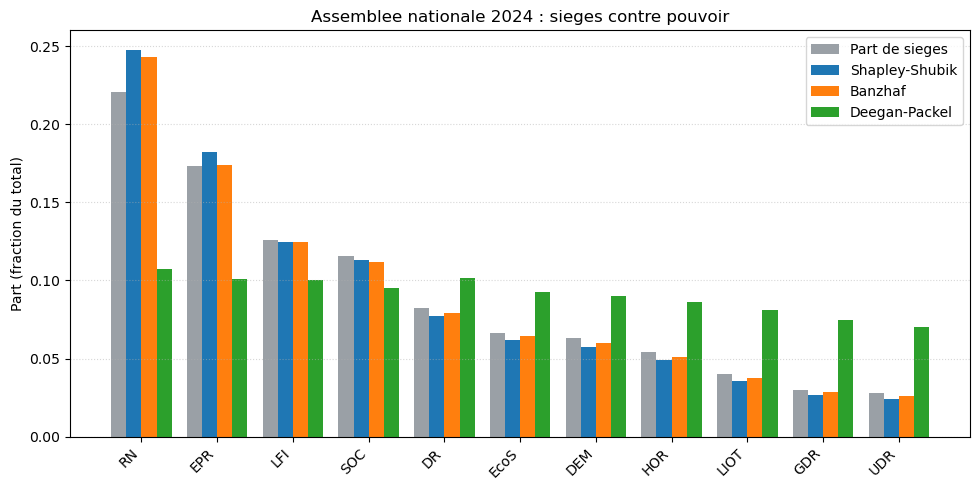

In [10]:
ss_a = shapley_shubik_exact(assemblee)
bz_a = banzhaf_normalized(assemblee)
dp_a = deegan_packel(assemblee)
fig = plot_power_vs_weight(assemblee, ss_a, bz_a, dp_a,
                           title="Assemblee nationale 2024 : sieges contre pouvoir")
plt.show()

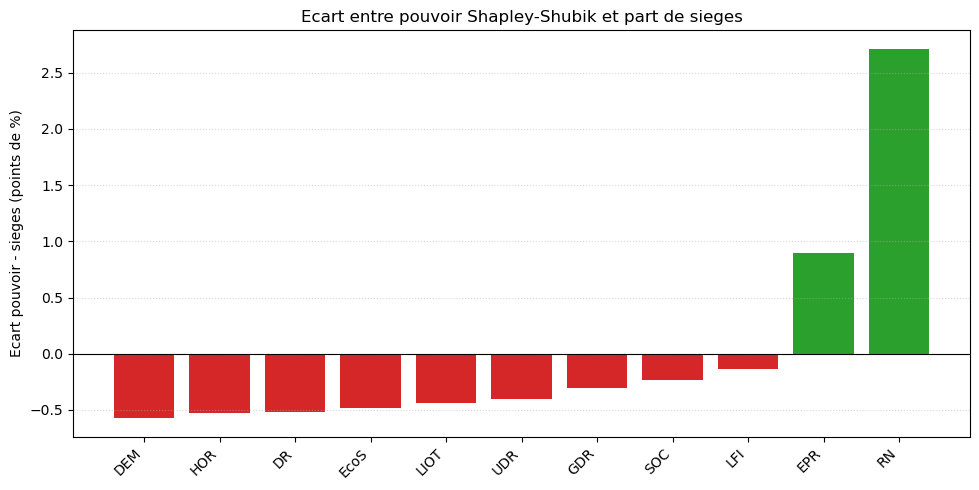

In [11]:
fig = plot_power_gap(assemblee, ss_a, "Shapley-Shubik")
plt.show()

### Comparaison 2024 / 2022

En 2022, la coalition presidentielle disposait d'une majorite relative bien plus
large (Renaissance a elle seule comptait 172 sieges). La distribution du pouvoir
y etait donc plus concentree qu'en 2024. La comparaison met en evidence l'effet
de la fragmentation de 2024 sur le pouvoir de pivot.

In [12]:
ass_2022 = majority_game_2022()
print("Pouvoir Shapley-Shubik du premier groupe :")
ss_2024 = shapley_shubik_exact(assemblee)
ss_2022 = shapley_shubik_exact(ass_2022)
print(f"  2024 - {assemblee.names[0]} ({assemblee.weights[0]} sieges) : {ss_2024[0]:.3f}")
print(f"  2022 - {ass_2022.names[0]} ({ass_2022.weights[0]} sieges) : {ss_2022[0]:.3f}")

Pouvoir Shapley-Shubik du premier groupe :
  2024 - RN (126 sieges) : 0.248
  2022 - RE (172 sieges) : 0.371


## 7. Application aux europeennes 2024 (methode D'Hondt)

Les europeennes utilisent la representation proportionnelle a la plus forte
moyenne (methode D'Hondt) avec un seuil de 5 %. Notre implementation reproduit
exactement la repartition officielle des 81 sieges francais. On calcule ensuite
le pouvoir de vote au sein de la delegation francaise, illustrant comment la
proportionnelle redistribue le pouvoir par rapport au scrutin majoritaire.

Repartition D'Hondt des 81 sieges (9 juin 2024) :
  RN   : 30 sieges
  RE   : 13 sieges
  PS   : 13 sieges
  LFI  :  9 sieges
  LR   :  6 sieges
  ECO  :  5 sieges
  REC  :  5 sieges


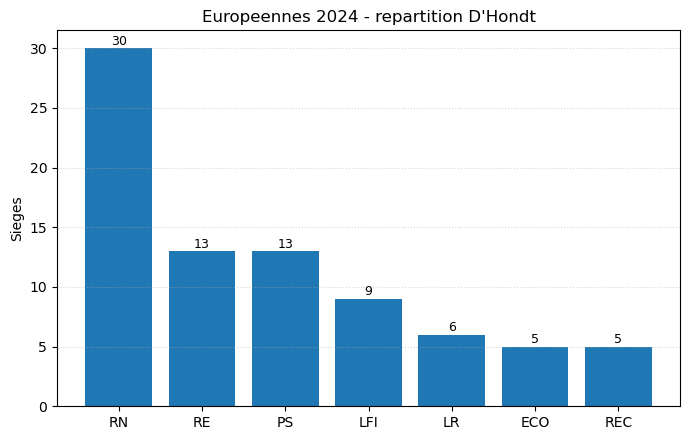

In [13]:
allocation = allocate_2024()
print("Repartition D'Hondt des 81 sieges (9 juin 2024) :")
for p in EUROPEENNES_2024:
    print(f"  {p.code:4s} : {allocation[p.code]:2d} sieges")
fig = plot_seats_bar(allocation, "Europeennes 2024 - repartition D'Hondt")
plt.show()

In [14]:
europe = majority_game_europeennes_2024()
comparison_table(europe)

,Groupe,Sieges,Part sieges %,Shapley-Shubik %,Banzhaf %,Deegan-Packel %,Ecart SS-sieges (pts)
0,RN,30,37.04,50.48,52.0,26.67,13.44
1,RE,13,16.05,13.81,12.0,11.50,-2.24
2,PS,13,16.05,13.81,12.0,11.50,-2.24
3,LFI,9,11.11,7.14,8.0,14.50,-3.97
4,LR,6,7.41,7.14,8.0,14.50,-0.26
5,ECO,5,6.17,3.81,4.0,10.67,-2.36
6,REC,5,6.17,3.81,4.0,10.67,-2.36


## 6bis. Coalitions reelles : modelisation en blocs

Le sujet demande de modeliser les coalitions (NUPES/NFP, Ensemble, RN, LR), et pas seulement les groupes isoles. On agrege les groupes en blocs politiques reels, on recalcule le pouvoir a l'echelle des blocs, puis on teste un contrefactuel : la gauche gagne-t-elle du pouvoir de pivot en s'unissant ?

In [15]:
from data.coalitions import bloc_game_2024, left_union_counterfactual
from analysis import comparison_table

blocs24 = bloc_game_2024()
print("Blocs 2024 :", dict(zip(blocs24.names, blocs24.weights)))
display(comparison_table(blocs24))

for annee in (2022, 2024):
    cf = left_union_counterfactual(annee)
    print(f"\nUnion de la gauche {annee} :")
    print(f"  part de sieges gauche : {cf['part_sieges_gauche']*100:5.1f} %")
    print(f"  pouvoir fragmente     : {cf['pouvoir_fragmente']*100:5.1f} %")
    print(f"  pouvoir uni (bloc)    : {cf['pouvoir_uni']*100:5.1f} %")
    print(f"  gain de l'union       : {cf['gain_union']*100:+5.1f} pts")

Blocs 2024 : {'NFP': 193, 'Ensemble': 166, 'RN': 126, 'DR': 47, 'LIOT': 23, 'UDR': 16}


,Groupe,Sieges,Part sieges %,Shapley-Shubik %,Banzhaf %,Deegan-Packel %,Ecart SS-sieges (pts)
0,NFP,193,33.80,33.33,33.33,33.33,-0.47
1,Ensemble,166,29.07,33.33,33.33,33.33,4.26
2,RN,126,22.07,33.33,33.33,33.33,11.27
3,DR,47,8.23,0.00,0.00,0.00,-8.23
4,LIOT,23,4.03,0.00,0.00,0.00,-4.03
5,UDR,16,2.80,0.00,0.00,0.00,-2.80



Union de la gauche 2022 :
  part de sieges gauche :  26.4 %
  pouvoir fragmente     :  24.1 %
  pouvoir uni (bloc)    :  16.7 %
  gain de l'union       :  -7.4 pts

Union de la gauche 2024 :
  part de sieges gauche :  33.8 %
  pouvoir fragmente     :  32.7 %
  pouvoir uni (bloc)    :  33.3 %
  gain de l'union       :  +0.7 pts


Lecture. A l'echelle des blocs de 2024, trois blocs (NFP, Ensemble, RN) se partagent le pouvoir a parts egales et les trois autres deviennent nuls : l'agregation change radicalement l'image donnee par les onze groupes. Le contrefactuel d'union revele un resultat contre-intuitif : en 2022, face a une coalition presidentielle proche de la majorite, unir la gauche en un seul bloc aurait detruit des positions de pivot (gain negatif) ; en 2024 l'union en apporte legerement.

## 6ter. Theorie contre observation : la motion de censure du 4 decembre 2024

Le pouvoir a priori suppose toutes les coalitions equiprobables. Un vote reel en selectionne une seule. Le 4 decembre 2024, la gauche (NFP) et l'extreme droite (RN, UDR) renversent le gouvernement Barnier par 331 voix. On confronte cette coalition observee a l'analyse theorique et on mesure l'ecart de discipline.

In [16]:
from data.votes_reels import (
    analyze_observed_vote, observed_versus_theoretical, CENSURE_BARNIER_2024,
)

obs = analyze_observed_vote(CENSURE_BARNIER_2024)
for cle, valeur in obs.items():
    print(f"{cle}: {valeur}")

print("\nClassement du pouvoir a priori (Shapley-Shubik) :")
for name, p in observed_versus_theoretical()['classement_pouvoir_a_priori']:
    print(f"  {name:6s} {p*100:5.1f} %")

titre: Motion de censure du gouvernement Barnier
date: 2024-12-04
coalition_observee: ('LFI', 'SOC', 'EcoS', 'GDR', 'RN', 'UDR')
sieges_si_discipline_parfaite: 335
voix_pour_observees: 331
majorite_requise: 288
ecart_discipline: 4
defections_internes: 6
ralliements_externes: 2
coalition_gagnante: True
coalition_minimale: False
groupes_critiques_observes: ('RN', 'LFI', 'SOC')

Classement du pouvoir a priori (Shapley-Shubik) :
  RN      24.8 %
  EPR     18.2 %
  LFI     12.5 %
  SOC     11.3 %
  DR       7.7 %
  EcoS     6.2 %
  DEM      5.7 %
  HOR      4.9 %
  LIOT     3.6 %
  GDR      2.7 %
  UDR      2.4 %


Lecture. Les groupes soutenant la motion totalisent 335 sieges mais seules 331 voix sont recueillies : l'ecart de 4 mesure l'imperfection de la discipline de parti que le modele de l'acteur unitaire suppose parfaite. La coalition observee est gagnante mais non minimale, et seuls RN, LFI et SOC y etaient critiques. Surtout, cette alliance NFP + RN, ideologiquement improbable, illustre la limite des indices a priori : aveugles a l'ideologie, ils ne peuvent pas anticiper quelles coalitions se forment reellement.

## 7bis. Impact du mode de scrutin sur le pouvoir

A suffrages constants (europeennes 2024), on fait varier la seule regle d'attribution des sieges. C'est le contrefactuel controle demande par le sujet : entre deux lignes, seul le mode de scrutin change, jamais l'electorat.

In [17]:
import pandas as pd
from data.modes_scrutin import compare_scrutin_modes_2024

display(pd.DataFrame(compare_scrutin_modes_2024()))

,Mode,Listes en sieges,Sieges RN,Part sieges RN %,Pouvoir RN (Shapley) %,Ecart pouvoir-sieges RN (pts)
0,D'Hondt (proportionnelle),7,30,37.0,50.5,13.4
1,Sainte-Lague (proportionnelle),7,29,35.8,50.5,14.7
2,Majoritaire integral,1,81,100.0,100.0,0.0


Lecture. Les deux variantes proportionnelles (D'Hondt, Sainte-Lague) laissent au RN un pouvoir de pivot quasi identique malgre des sieges differents, tandis que le scrutin majoritaire integral le fait passer de pivot a dictateur (100 % du pouvoir). Le mode de scrutin, a voix inchangees, deplace donc le pouvoir bien plus que la seule part de sieges ne le laisse voir.

## 7ter. Cout du calcul : exact contre Monte Carlo

Le calcul exact des indices est en O(2^n) : le denombrement exact des indices de Shapley et de Banzhaf est d'ailleurs #P-difficile (Deng et Papadimitriou, 1994). Sur l'Assemblee 2024 (onze groupes), on mesure l'erreur et le temps de l'approximation Monte Carlo face a l'enumeration exacte.

In [18]:
display(montecarlo_benchmark(majority_game_2024()))

,Methode,Echantillons,Erreur max,Temps (ms)
0,Exact,-,0.00000,14.5
1,Monte Carlo,1000,0.01132,1.8
2,Monte Carlo,10000,0.00732,18.4
3,Monte Carlo,100000,0.00236,187.3


## 9. Complements : couverture integrale de l'enonce

Cette section rassemble les quatre points qui restaient partiels : la preuve Z3 des axiomes de Deegan-Packel, l'extension regionale a prime majoritaire, les seuils strategiques de D'Hondt, et le detail par groupe du vote de censure.

### 9a. Preuve des axiomes de Deegan-Packel par Z3

Deegan-Packel n'est pas lineaire en les valeurs des coalitions : il se definit sur les coalitions gagnantes minimales. On encode ce predicat (une coalition gagne et tout retrait d'un membre la fait perdre), puis on prouve la symetrie, le joueur nul et l'efficacite par la meme methode que pour Shapley-Shubik : la negation de l'axiome est insatisfaisable. Les trois indices ont donc desormais leurs axiomes prouves formellement.

In [19]:
from formal.axioms import prove_all_deegan_packel_axioms

for n in (3, 4):
    print(f"n = {n}")
    for r in prove_all_deegan_packel_axioms(n):
        statut = 'prouve (UNSAT)' if r.proved else 'ECHEC'
        print(f"  {r.axiom:26s} : {statut}")

n = 3
  Deegan-Packel symetrie     : prouve (UNSAT)
  Deegan-Packel joueur nul   : prouve (UNSAT)
  Deegan-Packel efficacite   : prouve (UNSAT)
n = 4
  Deegan-Packel symetrie     : prouve (UNSAT)
  Deegan-Packel joueur nul   : prouve (UNSAT)
  Deegan-Packel efficacite   : prouve (UNSAT)


### 9b. Regionales 2021 : la prime majoritaire cree un dictateur

Le scrutin regional attribue un quart des sieges en prime a la liste arrivee en tete (article L338 du code electoral), puis repartit le reste a la plus forte moyenne. En Ile-de-France en 2021, la liste Pecresse obtient 125 sieges sur 209 avec 45,9 % des voix : au-dela de la majorite absolue, elle devient dictateur au sens des indices. La meme repartition en proportionnelle pure ne lui donnerait que la moitie du pouvoir de pivot.

In [20]:
import pandas as pd
from data.regionales import (
    allocate_idf_2021,
    majority_game_regionales_idf_2021,
    regionales_mode_impact,
)

alloc_idf = allocate_idf_2021()
print("Repartition des 209 sieges (Ile-de-France 2021) :", alloc_idf)

jeu_idf = majority_game_regionales_idf_2021()
ss_idf = shapley_shubik_exact(jeu_idf)
print("Pouvoir Shapley :", {jeu_idf.names[i]: round(ss_idf[i], 3) for i in jeu_idf.players})
pd.DataFrame(regionales_mode_impact())

Repartition des 209 sieges (Ile-de-France 2021) : {'LR': 125, 'EELV': 53, 'RN': 16, 'LREM': 15}
Pouvoir Shapley : {'LR': 1.0, 'EELV': 0.0, 'RN': 0.0, 'LREM': 0.0}


,Mode,Sieges vainqueur,Part sieges vainqueur %,Pouvoir vainqueur (Shapley) %,Vainqueur dictateur
0,Prime majoritaire (regionales),125,59.8,100.0,True
1,Proportionnelle pure (D'Hondt),96,45.9,50.0,False


### 9c. Seuils strategiques de la methode D'Hondt

Le dernier siege s'obtient au plus petit quotient gagnant : c'est le prix effectif d'un siege. On mesure, pour chaque liste des europeennes 2024, le nombre de suffrages qu'il lui aurait fallu pour un siege de plus. Ces seuils chiffrent la pression aux fusions ou aux scissions de listes.

In [21]:
import pandas as pd
from data.europeennes_dhondt import EUROPEENNES_2024, SEATS_2024, dhondt_marginal_votes

votes_eu = {p.code: p.votes for p in EUROPEENNES_2024}
marg = dhondt_marginal_votes(votes_eu, SEATS_2024, 0.05)
print("Quotient frontiere (prix d'un siege) :", round(marg["quotient_frontiere"]))
pd.DataFrame(
    sorted(
        ({"Liste": c, "Voix pour un siege de plus": n}
         for c, n in marg["voix_pour_un_siege_de_plus"].items()),
        key=lambda row: row["Voix pour un siege de plus"],
    )
)

Quotient frontiere (prix d'un siege) : 258865


,Liste,Voix pour un siege de plus
0,RE,11685
1,LR,17804
2,LFI,140737
3,ECO,191412
4,REC,199942
5,PS,201662
6,RN,258865


### 9d. Censure du 4 decembre 2024 : detail par groupe et discipline

Le seuil requis ce jour-la etait de 288 voix (trois sieges vacants), et non 289. L'ecart net entre les 335 sieges des groupes deposants et les 331 voix ne mesure pas directement les defections : il confond six defections internes a la coalition et deux voix venues de l'exterieur (un non-inscrit, un depute LIOT). Le detail par groupe le rend visible.

In [22]:
import pandas as pd
from data.votes_reels import CENSURE_BARNIER_2024, discipline_breakdown

b = discipline_breakdown(CENSURE_BARNIER_2024)
print(f"Sieges de la coalition : {b['sieges_coalition']}, voix internes : {b['voix_internes']}")
print(f"Defections internes : {b['defections_internes']}, ralliements externes : {b['ralliements_externes']}")
print(f"Ecart net sieges - voix : {b['ecart_net_sieges_voix']}")
pd.DataFrame(b["detail_par_groupe"])

Sieges de la coalition : 335, voix internes : 329
Defections internes : 6, ralliements externes : 2
Ecart net sieges - voix : 4


,groupe,sieges,voix_pour,defections
0,LFI,72,71,1
1,SOC,66,65,1
2,EcoS,38,38,0
3,GDR,17,16,1
4,RN,126,123,3
5,UDR,16,16,0


## 8. Conclusion

Ce projet a montre que le pouvoir de vote ne se confond pas avec le poids en
sieges. Trois enseignements ressortent :

- Le paradoxe du petit parti et le Conseil de securite illustrent des ecarts
  spectaculaires entre poids et pouvoir, retrouves exactement par nos indices.
- Le solveur SMT Z3 sert ici de verificateur symbolique : il calcule le statut
  des joueurs et les coalitions minimales, et il demontre formellement les
  axiomes des trois indices (Shapley-Shubik, Banzhaf et Deegan-Packel). La concordance systematique entre Z3 et
  l'enumeration combinatoire garantit la correction.
- Sur les donnees reelles, la fragmentation de l'Assemblee 2024 et la
  proportionnelle des europeennes redistribuent le pouvoir de pivot d'une maniere
  que le seul decompte des sieges ne laisse pas voir, en particulier sous
  l'indice de Deegan-Packel.
- Au-dela de l'ecart pouvoir-sieges, le projet confronte le pouvoir theorique a l'observation : modelisation des blocs et contrefactuel d'union de la gauche, confrontation a un vote reel (censure du 4 decembre 2024, ecart de discipline decompose par groupe), extension regionale a prime majoritaire, seuils strategiques de D'Hondt, et impact quantifie d'un changement de mode de scrutin a suffrages constants.

Le volet symbolique (encodage SMT et preuve des axiomes) distingue ce travail
d'une simple application numerique de la theorie des jeux : il place la mesure du
pouvoir sous la garantie d'un raisonnement formel verifiable.